In [1]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import colors
import math as math
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

Lectura de los datos en DataFrames

In [2]:
mc_data = pd.read_pickle('mc_data_all.pkl')
mc_data_BDT = pd.read_pickle('mc_data_BDT.pkl')

mc_data_MagUp = mc_data.query('(MAGFIELD == True)')
mc_data_MagDown = mc_data.query('(MAGFIELD == False)')

data24_MagUp = pd.read_pickle('data_BDT_MagUp.pkl')
data24_MagDown = pd.read_pickle('data_BDT_MagDown.pkl')

data24 = pd.read_pickle('data_BDT_combined.pkl')

In [3]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

mc_signal = mc_data.copy()

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

# # Filtrar los datos según las condiciones dadas
# mc_signal3 = mc_signal.query("(p_TRUEID == 2212) & (pim_TRUEID == -211) & (p_MC_GD_MOTHER_ID == 5122) & (pim_MC_GD_MOTHER_ID == 5122) & (p_MC_MOTHER_ID == 3122) & (pim_MC_MOTHER_ID == 3122)")
# mc_signal4 = mc_signal.query("(p_TRUEID == -2212) & (pim_TRUEID == 211) & (p_MC_GD_MOTHER_ID == -5122) & (pim_MC_GD_MOTHER_ID == -5122) & (p_MC_MOTHER_ID == -3122) & (pim_MC_MOTHER_ID == -3122)")

mc_signal3 = mc_signal.query(particulas)
mc_signal4 = mc_signal.query(antiparticulas)

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    total_momentum = pplus_4 + pminus_4
    pV0 = total_momentum.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

# Calcular para partículas
particle = True

mc_signal['TRUE_alpha'] = np.nan
mc_signal['TRUE_pT'] = np.nan

mc_signal['TRUE_alpha_anti'] = np.nan
mc_signal['TRUE_pT_anti'] = np.nan

for index, row in mc_signal3.iterrows():
    pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
    pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
    pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mc_signal.at[index, 'TRUE_alpha'] = alpha
    mc_signal.at[index, 'TRUE_pT'] = pT

# Calcular para antipartículas
particle = False

for index, row in mc_signal4.iterrows():
    pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
    pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
    pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mc_signal.at[index, 'TRUE_alpha_anti'] = alpha
    mc_signal.at[index, 'TRUE_pT_anti'] = pT

mc_data['TRUE_alpha'] =  mc_signal['TRUE_alpha'].copy()
mc_data['TRUE_alpha_anti'] =  mc_signal['TRUE_alpha_anti'].copy()
mc_data['TRUE_pT'] =  mc_signal['TRUE_pT'].copy()
mc_data['TRUE_pT_anti'] =  mc_signal['TRUE_pT_anti'].copy()

mc_data['TRUE_alpha_combined'] = mc_data['TRUE_alpha'].combine_first(mc_data['TRUE_alpha_anti'])
mc_data['TRUE_pT_combined'] = mc_data['TRUE_pT'].combine_first(mc_data['TRUE_pT_anti'])

# Mostrar resultados
print("Partículas:")
print(mc_data['TRUE_alpha_combined'])

print("\nAntipartículas:")
print(mc_data['TRUE_pT_combined'])


Welcome to JupyROOT 6.30/04


/tmp/javeser/ipykernel_28334/3849319662.py:79: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_data['TRUE_alpha'] =  mc_signal['TRUE_alpha'].copy()
/tmp/javeser/ipykernel_28334/3849319662.py:80: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_data['TRUE_alpha_anti'] =  mc_signal['TRUE_alpha_anti'].copy()
/tmp/javeser/ipykernel_28334/3849319662.py:81: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at 

Partículas:
0       -0.784126
1        0.821004
2        0.722349
3        0.762896
4        0.824587
           ...   
60158         NaN
60159   -0.747277
60160         NaN
60161    0.576347
60162         NaN
Name: TRUE_alpha_combined, Length: 60163, dtype: float64

Antipartículas:
0         0.613654
1        70.045499
2        99.104033
3        92.385248
4        67.932751
           ...    
60158          NaN
60159    95.668824
60160          NaN
60161    77.374523
60162          NaN
Name: TRUE_pT_combined, Length: 60163, dtype: float64


In [4]:
mc_signal['p_PX_V']

0         288.351258
1       -2222.077502
2        1815.390763
3        3000.034926
4        2762.213128
            ...     
60158     408.518930
60159    -620.444489
60160    1128.660565
60161     679.372218
60162     -83.285863
Name: p_PX_V, Length: 60163, dtype: float64

In [5]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

mc_signal = mc_data.copy()

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

# Filtrar los datos según las condiciones dadas
mc_signal3 = mc_signal.query(particulas)
mc_signal4 = mc_signal.query(antiparticulas)
def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    total_momentum = pplus_4 + pminus_4
    pV0 = total_momentum.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

# Calcular para partículas
particle = True

mc_signal['alpha'] = np.nan
mc_signal['pT'] = np.nan

mc_signal['alpha_anti'] = np.nan
mc_signal['pT_anti'] = np.nan

for index, row in mc_signal3.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mc_signal.at[index, 'alpha'] = alpha
    mc_signal.at[index, 'pT'] = pT

# Calcular para antipartículas
particle = False

for index, row in mc_signal4.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mc_signal.at[index, 'alpha_anti'] = alpha
    mc_signal.at[index, 'pT_anti'] = pT

mc_data['alpha'] =  mc_signal['alpha'].copy()
mc_data['alpha_anti'] =  mc_signal['alpha_anti'].copy()
mc_data['pT'] =  mc_signal['pT'].copy()
mc_data['pT_anti'] =  mc_signal['pT_anti'].copy()

mc_data['alpha_combined'] = mc_data['alpha'].combine_first(mc_data['alpha_anti'])
mc_data['pT_combined'] = mc_data['pT'].combine_first(mc_data['pT_anti'])

# Mostrar resultados
print("Partículas:")
print(mc_data['alpha_combined'])

print("\nAntipartículas:")
print(mc_data['pT_combined'])


Partículas:
0       -0.743510
1        0.730630
2        0.771224
3        0.775246
4        0.738295
           ...   
60158    0.405227
60159   -0.628652
60160    0.460045
60161    0.622233
60162    0.055739
Name: alpha_combined, Length: 60163, dtype: float64

Antipartículas:
0        192.927116
1        113.560084
2        719.268581
3        352.174991
4        229.701112
            ...    
60158    251.882946
60159    267.602927
60160    802.160338
60161    119.660256
60162    317.891435
Name: pT_combined, Length: 60163, dtype: float64


/tmp/javeser/ipykernel_28334/2296932577.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_data['alpha'] =  mc_signal['alpha'].copy()
/tmp/javeser/ipykernel_28334/2296932577.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_data['alpha_anti'] =  mc_signal['alpha_anti'].copy()
/tmp/javeser/ipykernel_28334/2296932577.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat

In [6]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

mc_signal = mc_data_BDT.copy()

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

# Filtrar los datos según las condiciones dadas
mc_signal3 = mc_signal.query(particulas)
mc_signal4 = mc_signal.query(antiparticulas)
def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    total_momentum = pplus_4 + pminus_4
    pV0 = total_momentum.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

# Calcular para partículas
particle = True

mc_signal['alpha'] = np.nan
mc_signal['pT'] = np.nan

mc_signal['alpha_anti'] = np.nan
mc_signal['pT_anti'] = np.nan

for index, row in mc_signal3.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mc_signal.at[index, 'alpha'] = alpha
    mc_signal.at[index, 'pT'] = pT

# Calcular para antipartículas
particle = False

for index, row in mc_signal4.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mc_signal.at[index, 'alpha_anti'] = alpha
    mc_signal.at[index, 'pT_anti'] = pT

mc_data_BDT['alpha'] =  mc_signal['alpha'].copy()
mc_data_BDT['alpha_anti'] =  mc_signal['alpha_anti'].copy()
mc_data_BDT['pT'] =  mc_signal['pT'].copy()
mc_data_BDT['pT_anti'] =  mc_signal['pT_anti'].copy()

mc_data_BDT['alpha_combined'] = mc_data_BDT['alpha'].combine_first(mc_data_BDT['alpha_anti'])
mc_data_BDT['pT_combined'] = mc_data_BDT['pT'].combine_first(mc_data_BDT['pT_anti'])

# Mostrar resultados
print("Partículas:")
print(mc_data_BDT['alpha_combined'])

print("\nAntipartículas:")
print(mc_data_BDT['pT_combined'])


Partículas:
1        0.730630
2        0.771224
5       -0.738889
6       -0.767841
9       -0.723169
           ...   
60107    0.737862
60122    0.693260
60140    0.604063
60152    0.843565
60156   -0.457225
Name: alpha_combined, Length: 36100, dtype: float64

Antipartículas:
1        113.560084
2        719.268581
5         83.734816
6        568.544347
9        205.299799
            ...    
60107    288.262105
60122    161.334057
60140    254.700948
60152     86.150880
60156    341.597338
Name: pT_combined, Length: 36100, dtype: float64


/tmp/javeser/ipykernel_28334/819531458.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_data_BDT['alpha'] =  mc_signal['alpha'].copy()
/tmp/javeser/ipykernel_28334/819531458.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_data_BDT['alpha_anti'] =  mc_signal['alpha_anti'].copy()
/tmp/javeser/ipykernel_28334/819531458.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.c

In [7]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

mc_signal = data24.copy()

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

# Filtrar los datos según las condiciones dadas
mc_signal3 = mc_signal.query(particulas)
mc_signal4 = mc_signal.query(antiparticulas)
def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    total_momentum = pplus_4 + pminus_4
    pV0 = total_momentum.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

# Calcular para partículas
particle = True

mc_signal['alpha'] = np.nan
mc_signal['pT'] = np.nan

mc_signal['alpha_anti'] = np.nan
mc_signal['pT_anti'] = np.nan

for index, row in mc_signal3.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mc_signal.at[index, 'alpha'] = alpha
    mc_signal.at[index, 'pT'] = pT

# Calcular para antipartículas
particle = False

for index, row in mc_signal4.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mc_signal.at[index, 'alpha_anti'] = alpha
    mc_signal.at[index, 'pT_anti'] = pT

data24['alpha'] =  mc_signal['alpha'].copy()
data24['alpha_anti'] =  mc_signal['alpha_anti'].copy()
data24['pT'] =  mc_signal['pT'].copy()
data24['pT_anti'] =  mc_signal['pT_anti'].copy()

data24['alpha_combined'] = data24['alpha'].combine_first(data24['alpha_anti'])
data24['pT_combined'] = data24['pT'].combine_first(data24['pT_anti'])

# Mostrar resultados
print("Partículas:")
print(data24['alpha_combined'])

print("\nAntipartículas:")
print(data24['pT_combined'])


Partículas:
106        0.762205
127        0.743703
208        0.764626
289        0.740150
362        0.731555
             ...   
3164483    0.631685
3168723    0.645594
3168976    0.811390
3169668   -0.595801
3169833   -0.754099
Name: alpha_combined, Length: 31738, dtype: float64

Antipartículas:
106        216.978910
127         31.483678
208         27.061595
289         36.656425
362        178.267113
              ...    
3164483    324.473709
3168723    451.546826
3168976    461.946077
3169668    269.440403
3169833    448.352298
Name: pT_combined, Length: 31738, dtype: float64


/tmp/javeser/ipykernel_28334/2722300776.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data24['alpha'] =  mc_signal['alpha'].copy()
/tmp/javeser/ipykernel_28334/2722300776.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data24['alpha_anti'] =  mc_signal['alpha_anti'].copy()
/tmp/javeser/ipykernel_28334/2722300776.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(a

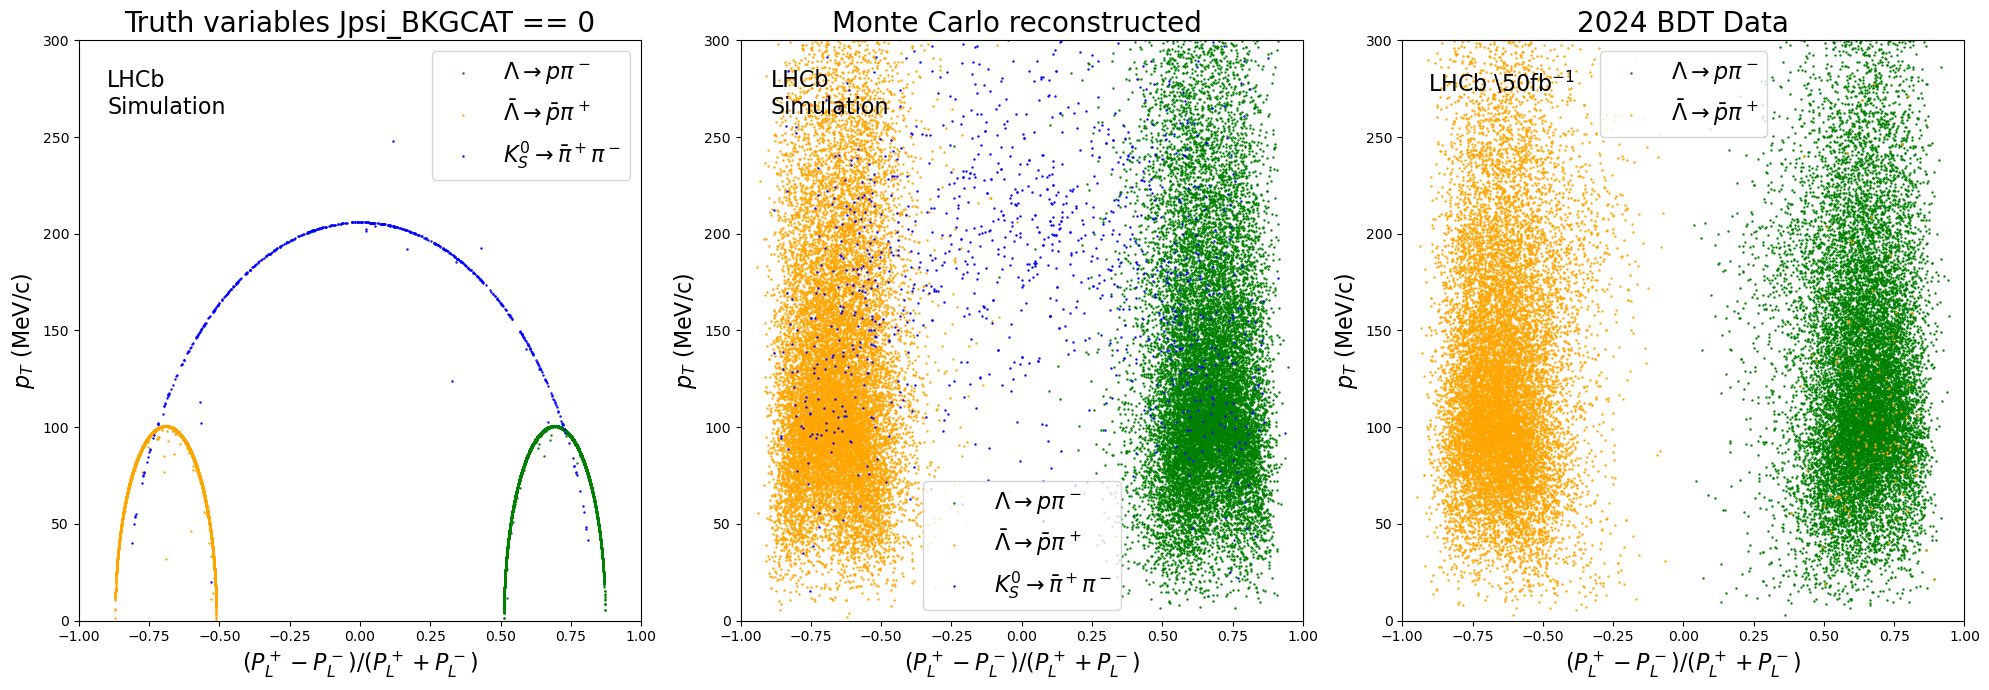

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(20, 7))  # 4 filas, 1 columna
tam = 0.5
# Primer gráfico
axs[0].scatter(mc_data.query('(Lb_BKGCAT == 0 )')['TRUE_alpha'],mc_data.query('(Lb_BKGCAT == 0 )')['TRUE_pT'], c='green', s=tam, label=r'$\Lambda \to p \pi^-$')
axs[0].scatter(mc_data.query('(Lb_BKGCAT == 0 )')['TRUE_alpha_anti'],mc_data.query('(Lb_BKGCAT == 0 )')['TRUE_pT_anti'], c='orange', s=tam, label=r'$\bar\Lambda \to \bar p \pi^+$')
axs[0].scatter(mc_data.query('(p_MC_MOTHER_ID == 310)&(pim_MC_MOTHER_ID == 310)&(p_MC_GD_MOTHER_ID == 311)&(pim_MC_GD_MOTHER_ID == 311)')['TRUE_alpha_combined'],mc_data.query('(p_MC_MOTHER_ID == 310)&(pim_MC_MOTHER_ID == 310)&(p_MC_GD_MOTHER_ID == 311)&(pim_MC_GD_MOTHER_ID == 311)')['TRUE_pT_combined'], c='blue', s=tam, label=r'$K_S^0 \to \bar \pi^+ \pi^-$')
axs[0].set_xlim(-1, 1)
# axs[0].scatter(mc_data.query('(p_TRUEID != 310)&(pim_TRUEID != 310) & (p_TRUEID != 2212)&(pim_TRUEID != 2212)&(p_MC_GD_MOTHER_ID == 311)&(pim_MC_GD_MOTHER_ID == 311)')['TRUE_alpha'],mc_data.query('(p_TRUEID != 310)&(pim_TRUEID != 310) & (p_TRUEID != 2212)&(pim_TRUEID != 2212)&(p_MC_GD_MOTHER_ID == 311)&(pim_MC_GD_MOTHER_ID == 311)')['TRUE_pT'], c='blue', s=0.05, label='Lambda True')
axs[0].set_ylim(0, 300)
axs[0].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$', fontsize= 16)
axs[0].set_ylabel('$p_T$ (MeV/c)', fontsize= 16)
axs[0].legend(fontsize= 16)
axs[0].set_title('Truth variables Jpsi_BKGCAT == 0', fontsize= 20)

# Añadir texto "LHCb\nSimulation" al primer gráfico
axs[0].text(0.05, 0.95, "LHCb\nSimulation", transform=axs[0].transAxes, fontsize=16, color='Black', ha='left', va='top')


# Primer gráfico
axs[1].scatter(mc_data.query('(p_MC_MOTHER_ID != 310)&(pim_MC_MOTHER_ID != -310)&(Lb_BKGCAT == 0 )')['alpha'],mc_data.query('(p_MC_MOTHER_ID != 310)&(pim_MC_MOTHER_ID != -310)&(Lb_BKGCAT == 0 )')['pT'], c='green', s=tam, label=r'$\Lambda \to p \pi^-$')
axs[1].scatter(mc_data.query('(p_MC_MOTHER_ID != -310)&(pim_MC_MOTHER_ID != 310)&(Lb_BKGCAT == 0 )')['alpha_anti'],mc_data.query('(p_MC_MOTHER_ID != -310)&(pim_MC_MOTHER_ID != 310)&(Lb_BKGCAT == 0 )')['pT_anti'], c='orange', s=tam, label=r'$\bar\Lambda \to \bar p \pi^+$')
axs[1].scatter(mc_data.query('(p_MC_MOTHER_ID == 310)&(pim_MC_MOTHER_ID == 310)')['alpha_combined'],mc_data.query('(p_MC_MOTHER_ID == 310)&(pim_MC_MOTHER_ID == 310)')['pT_combined'], c='blue', s=tam, label=r'$K_S^0 \to \bar \pi^+ \pi^-$')
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(0, 300)
axs[1].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$', fontsize= 16)
axs[1].set_ylabel('$p_T$ (MeV/c)', fontsize= 16)
axs[1].legend(fontsize= 16)
axs[1].set_title('Monte Carlo reconstructed ', fontsize= 20)

# Añadir texto "LHCb\nSimulation" al primer gráfico
axs[1].text(1.23, 0.95, "LHCb\nSimulation", transform=axs[0].transAxes, fontsize=16, color='Black', ha='left', va='top')

# Tercer gráfico
axs[2].scatter(data24.query(' (p_QOVERP > 0)')['alpha_combined'],data24.query(' (p_QOVERP > 0) ')['pT_combined'], c='green', s=tam, label=r'$\Lambda \to p \pi^-$')
axs[2].scatter(data24.query('(p_QOVERP < 0)')['alpha_combined'],data24.query('(p_QOVERP < 0) ')['pT_combined'], c='orange', s=tam, label=r'$\bar\Lambda \to \bar p \pi^+$')
# axs[2].scatter(signal_data.query('(prob1 > 0.9)')['alpha_combined'],signal_data.query('(prob1 > 0.9)')['pT_combined'], c='orange', s=0.05, label='Anti-Lambda', alpha = 0.5)
axs[2].set_xlim(-1, 1)
axs[2].set_ylim(0, 300)
axs[2].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$', fontsize= 16)
axs[2].set_ylabel('$p_T$ (MeV/c)', fontsize= 16)
axs[2].legend(fontsize= 16)
axs[2].set_title('2024 BDT Data', fontsize= 20)

# Añadir texto "LHCb\nSimulation" al primer gráfico
axs[2].text(2.40, 0.95, r"LHCb \50fb$^{-1}$", transform=axs[0].transAxes, fontsize=16, color='Black', ha='left', va='top')


plt.tight_layout()
plt.show()


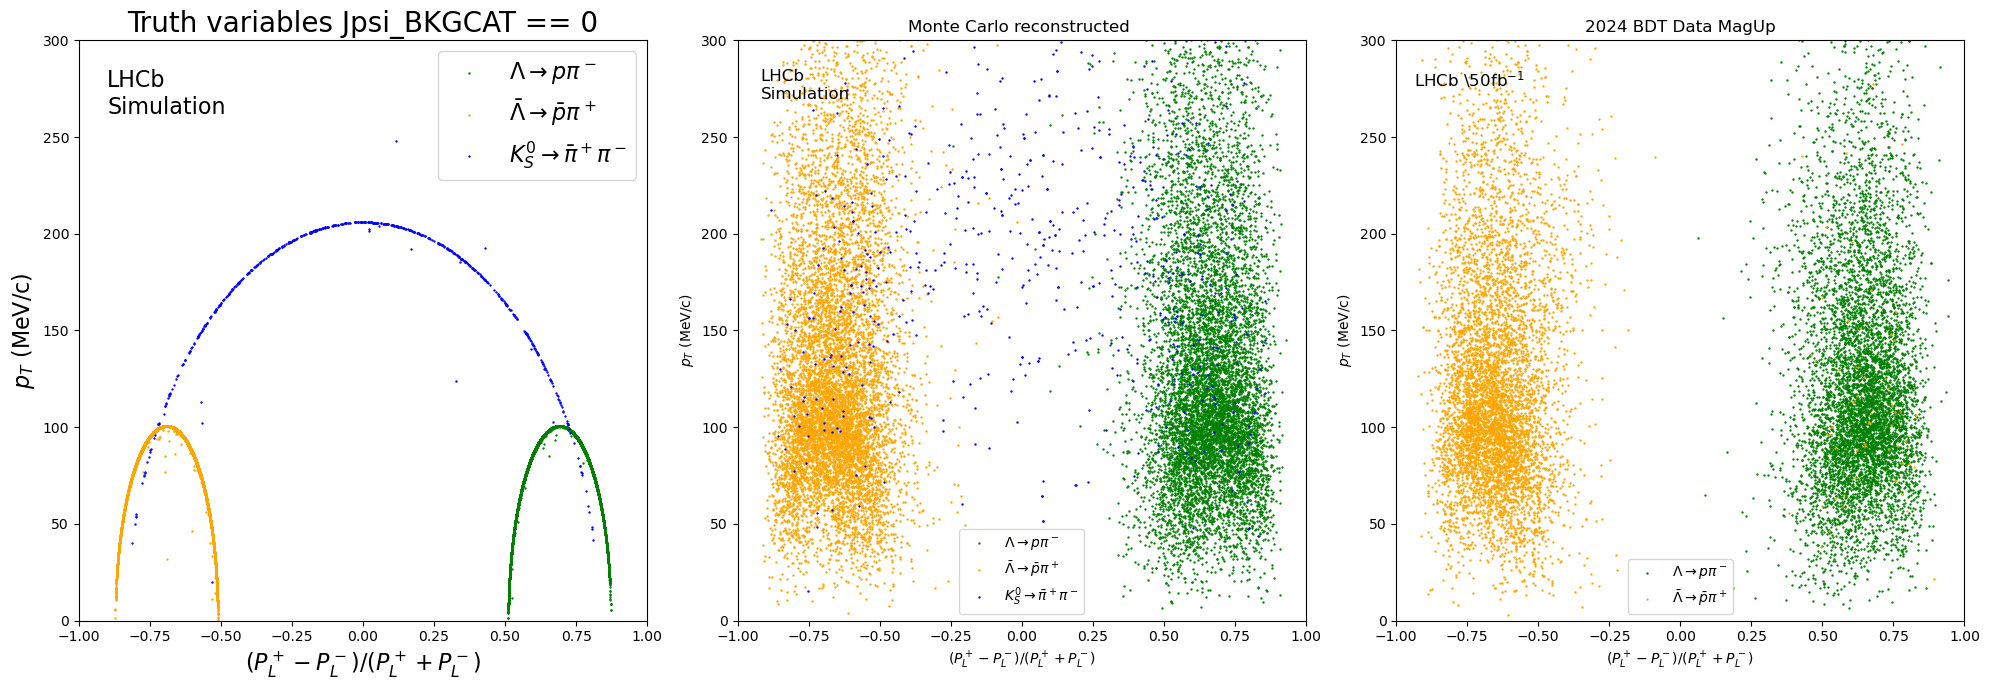

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(20, 7))  # 4 filas, 1 columna
tam = 0.5
# Primer gráfico
axs[0].scatter(mc_data.query('(Lb_BKGCAT == 0 )')['TRUE_alpha'],mc_data.query('(Lb_BKGCAT == 0 )')['TRUE_pT'], c='green', s=tam, label=r'$\Lambda \to p \pi^-$')
axs[0].scatter(mc_data.query('(Lb_BKGCAT == 0 )')['TRUE_alpha_anti'],mc_data.query('(Lb_BKGCAT == 0 )')['TRUE_pT_anti'], c='orange', s=tam, label=r'$\bar\Lambda \to \bar p \pi^+$')
axs[0].scatter(mc_data.query('(p_MC_MOTHER_ID == 310)&(pim_MC_MOTHER_ID == 310)&(p_MC_GD_MOTHER_ID == 311)&(pim_MC_GD_MOTHER_ID == 311)')['TRUE_alpha_combined'],mc_data.query('(p_MC_MOTHER_ID == 310)&(pim_MC_MOTHER_ID == 310)&(p_MC_GD_MOTHER_ID == 311)&(pim_MC_GD_MOTHER_ID == 311)')['TRUE_pT_combined'], c='blue', s=tam, label=r'$K_S^0 \to \bar \pi^+ \pi^-$')
axs[0].set_xlim(-1, 1)
# axs[0].scatter(mc_data.query('(p_TRUEID != 310)&(pim_TRUEID != 310) & (p_TRUEID != 2212)&(pim_TRUEID != 2212)&(p_MC_GD_MOTHER_ID == 311)&(pim_MC_GD_MOTHER_ID == 311)')['TRUE_alpha'],mc_data.query('(p_TRUEID != 310)&(pim_TRUEID != 310) & (p_TRUEID != 2212)&(pim_TRUEID != 2212)&(p_MC_GD_MOTHER_ID == 311)&(pim_MC_GD_MOTHER_ID == 311)')['TRUE_pT'], c='blue', s=0.05, label='Lambda True')
axs[0].set_ylim(0, 300)
axs[0].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$', fontsize= 16)
axs[0].set_ylabel('$p_T$ (MeV/c)', fontsize= 16)
axs[0].legend(fontsize= 16)
axs[0].set_title('Truth variables Jpsi_BKGCAT == 0', fontsize= 20)

# Añadir texto "LHCb\nSimulation" al primer gráfico
axs[0].text(0.05, 0.95, "LHCb\nSimulation", transform=axs[0].transAxes, fontsize=16, color='Black', ha='left', va='top')


# Primer gráfico
axs[1].scatter(mc_data.query('(p_MC_MOTHER_ID != 310)&(pim_MC_MOTHER_ID != -310)&(Lb_BKGCAT == 0 ) & (MAGFIELD == True)')['alpha'],mc_data.query('(p_MC_MOTHER_ID != 310) & (MAGFIELD == True)&(pim_MC_MOTHER_ID != -310)&(Lb_BKGCAT == 0 )')['pT'], c='green', s=tam, label=r'$\Lambda \to p \pi^-$')
axs[1].scatter(mc_data.query('(p_MC_MOTHER_ID != -310)&(pim_MC_MOTHER_ID != 310)&(Lb_BKGCAT == 0 ) & (MAGFIELD == True)')['alpha_anti'],mc_data.query('(p_MC_MOTHER_ID != -310) & (MAGFIELD == True)&(pim_MC_MOTHER_ID != 310)&(Lb_BKGCAT == 0 )')['pT_anti'], c='orange', s=tam, label=r'$\bar\Lambda \to \bar p \pi^+$')
axs[1].scatter(mc_data.query('(p_MC_MOTHER_ID == 310)&(pim_MC_MOTHER_ID == 310) & (MAGFIELD == True)')['alpha_combined'],mc_data.query('(p_MC_MOTHER_ID == 310) & (MAGFIELD == True)&(pim_MC_MOTHER_ID == 310)')['pT_combined'], c='blue', s=tam, label=r'$K_S^0 \to \bar \pi^+ \pi^-$')
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(0, 300)
axs[1].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[1].set_ylabel('$p_T$ (MeV/c)')
axs[1].legend()
axs[1].set_title('Monte Carlo reconstructed ')

# Añadir texto "LHCb\nSimulation" al primer gráfico
axs[1].text(1.2, 0.95, "LHCb\nSimulation", transform=axs[0].transAxes, fontsize=12, color='Black', ha='left', va='top')

# Tercer gráfico
axs[2].scatter(data24.query(' (p_QOVERP > 0) & (MAGFIELD == True)')['alpha_combined'],data24.query(' (p_QOVERP > 0)  & (MAGFIELD == True)')['pT_combined'], c='green', s=tam, label=r'$\Lambda \to p \pi^-$')
axs[2].scatter(data24.query('(p_QOVERP < 0) & (MAGFIELD == True)')['alpha_combined'],data24.query('(p_QOVERP < 0)  & (MAGFIELD == True)')['pT_combined'], c='orange', s=tam, label=r'$\bar\Lambda \to \bar p \pi^+$')
# axs[2].scatter(signal_data.query('(prob1 > 0.9)')['alpha_combined'],signal_data.query('(prob1 > 0.9)')['pT_combined'], c='orange', s=0.05, label='Anti-Lambda', alpha = 0.5)
axs[2].set_xlim(-1, 1)
axs[2].set_ylim(0, 300)
axs[2].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[2].set_ylabel('$p_T$ (MeV/c)')
axs[2].legend()
axs[2].set_title('2024 BDT Data MagUp')

# Añadir texto "LHCb\nSimulation" al primer gráfico
axs[2].text(2.35, 0.95, r"LHCb \50fb$^{-1}$", transform=axs[0].transAxes, fontsize=12, color='Black', ha='left', va='top')


plt.tight_layout()
plt.show()


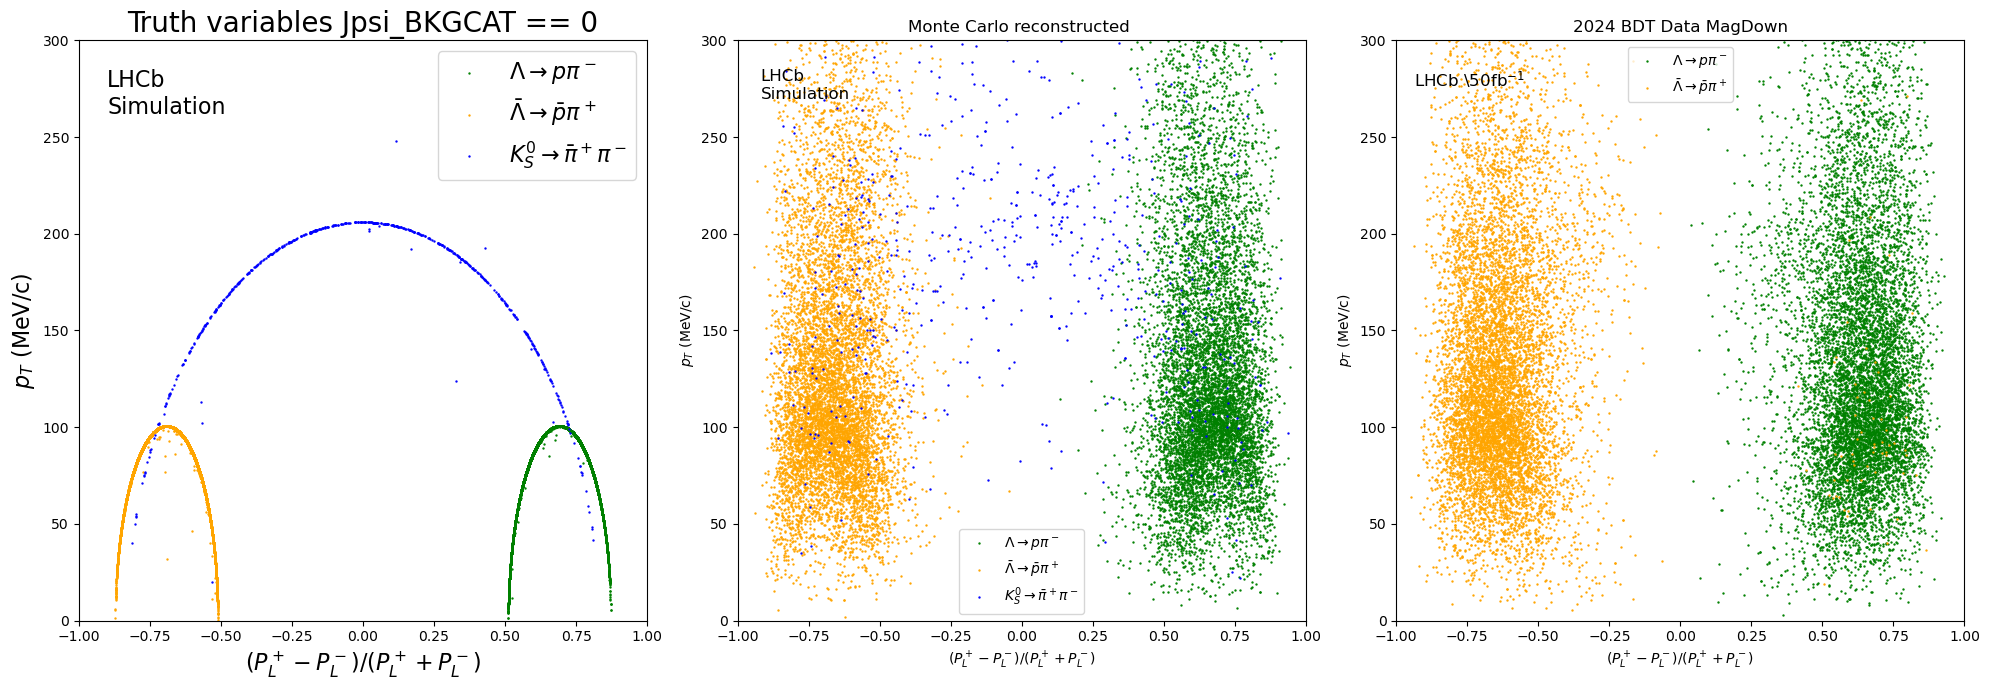

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(20, 7))  # 4 filas, 1 columna
tam = 0.5
# Primer gráfico
axs[0].scatter(mc_data.query('(Lb_BKGCAT == 0 )')['TRUE_alpha'],mc_data.query('(Lb_BKGCAT == 0 )')['TRUE_pT'], c='green', s=tam, label=r'$\Lambda \to p \pi^-$')
axs[0].scatter(mc_data.query('(Lb_BKGCAT == 0 )')['TRUE_alpha_anti'],mc_data.query('(Lb_BKGCAT == 0 )')['TRUE_pT_anti'], c='orange', s=tam, label=r'$\bar\Lambda \to \bar p \pi^+$')
axs[0].scatter(mc_data.query('(p_MC_MOTHER_ID == 310)&(pim_MC_MOTHER_ID == 310)&(p_MC_GD_MOTHER_ID == 311)&(pim_MC_GD_MOTHER_ID == 311)')['TRUE_alpha_combined'],mc_data.query('(p_MC_MOTHER_ID == 310)&(pim_MC_MOTHER_ID == 310)&(p_MC_GD_MOTHER_ID == 311)&(pim_MC_GD_MOTHER_ID == 311)')['TRUE_pT_combined'], c='blue', s=tam, label=r'$K_S^0 \to \bar \pi^+ \pi^-$')
axs[0].set_xlim(-1, 1)
# axs[0].scatter(mc_data.query('(p_TRUEID != 310)&(pim_TRUEID != 310) & (p_TRUEID != 2212)&(pim_TRUEID != 2212)&(p_MC_GD_MOTHER_ID == 311)&(pim_MC_GD_MOTHER_ID == 311)')['TRUE_alpha'],mc_data.query('(p_TRUEID != 310)&(pim_TRUEID != 310) & (p_TRUEID != 2212)&(pim_TRUEID != 2212)&(p_MC_GD_MOTHER_ID == 311)&(pim_MC_GD_MOTHER_ID == 311)')['TRUE_pT'], c='blue', s=0.05, label='Lambda True')
axs[0].set_ylim(0, 300)
axs[0].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$', fontsize= 16)
axs[0].set_ylabel('$p_T$ (MeV/c)', fontsize= 16)
axs[0].legend(fontsize= 16)
axs[0].set_title('Truth variables Jpsi_BKGCAT == 0', fontsize= 20)

# Añadir texto "LHCb\nSimulation" al primer gráfico
axs[0].text(0.05, 0.95, "LHCb\nSimulation", transform=axs[0].transAxes, fontsize=16, color='Black', ha='left', va='top')


# Primer gráfico
axs[1].scatter(mc_data.query('(p_MC_MOTHER_ID != 310)&(pim_MC_MOTHER_ID != -310)&(Lb_BKGCAT == 0 ) & (MAGFIELD == False)')['alpha'],mc_data.query('(p_MC_MOTHER_ID != 310) & (MAGFIELD == False)&(pim_MC_MOTHER_ID != -310)&(Lb_BKGCAT == 0 )')['pT'], c='green', s=tam, label=r'$\Lambda \to p \pi^-$')
axs[1].scatter(mc_data.query('(p_MC_MOTHER_ID != -310)&(pim_MC_MOTHER_ID != 310)&(Lb_BKGCAT == 0 ) & (MAGFIELD == False)')['alpha_anti'],mc_data.query('(p_MC_MOTHER_ID != -310) & (MAGFIELD == False)&(pim_MC_MOTHER_ID != 310)&(Lb_BKGCAT == 0 )')['pT_anti'], c='orange', s=tam, label=r'$\bar\Lambda \to \bar p \pi^+$')
axs[1].scatter(mc_data.query('(p_MC_MOTHER_ID == 310)&(pim_MC_MOTHER_ID == 310) & (MAGFIELD == False)')['alpha_combined'],mc_data.query('(p_MC_MOTHER_ID == 310) & (MAGFIELD == False)&(pim_MC_MOTHER_ID == 310)')['pT_combined'], c='blue', s=tam, label=r'$K_S^0 \to \bar \pi^+ \pi^-$')
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(0, 300)
axs[1].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[1].set_ylabel('$p_T$ (MeV/c)')
axs[1].legend()
axs[1].set_title('Monte Carlo reconstructed ')

# Añadir texto "LHCb\nSimulation" al primer gráfico
axs[1].text(1.2, 0.95, "LHCb\nSimulation", transform=axs[0].transAxes, fontsize=12, color='Black', ha='left', va='top')

# Tercer gráfico
axs[2].scatter(data24.query(' (p_QOVERP > 0) & (MAGFIELD == False)')['alpha_combined'],data24.query(' (p_QOVERP > 0)  & (MAGFIELD == False)')['pT_combined'], c='green', s=tam, label=r'$\Lambda \to p \pi^-$')
axs[2].scatter(data24.query('(p_QOVERP < 0) & (MAGFIELD == False)')['alpha_combined'],data24.query('(p_QOVERP < 0)  & (MAGFIELD == False)')['pT_combined'], c='orange', s=tam, label=r'$\bar\Lambda \to \bar p \pi^+$')
# axs[2].scatter(signal_data.query('(prob1 > 0.9)')['alpha_combined'],signal_data.query('(prob1 > 0.9)')['pT_combined'], c='orange', s=0.05, label='Anti-Lambda', alpha = 0.5)
axs[2].set_xlim(-1, 1)
axs[2].set_ylim(0, 300)
axs[2].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[2].set_ylabel('$p_T$ (MeV/c)')
axs[2].legend()
axs[2].set_title('2024 BDT Data MagDown')

# Añadir texto "LHCb\nSimulation" al primer gráfico
axs[2].text(2.35, 0.95, r"LHCb \50fb$^{-1}$", transform=axs[0].transAxes, fontsize=12, color='Black', ha='left', va='top')


plt.tight_layout()
plt.show()


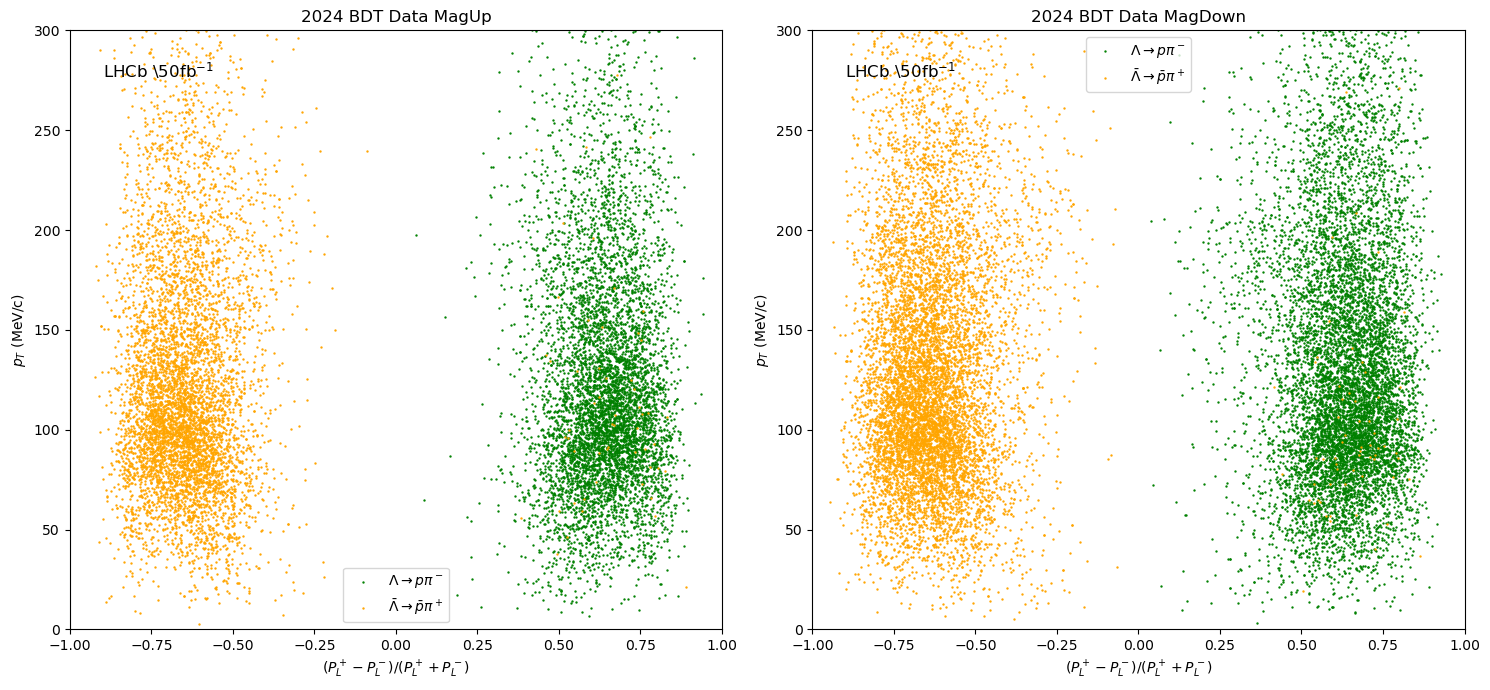

In [11]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(15, 7))  # 1 fila, 2 columnas
tam = 0.5

# Gráfico para MagUp
axs[0].scatter(data24.query(' (p_QOVERP > 0) & (MAGFIELD == True)')['alpha_combined'], 
               data24.query(' (p_QOVERP > 0)  & (MAGFIELD == True)')['pT_combined'], 
               c='green', s=tam, label=r'$\Lambda \to p \pi^-$')
axs[0].scatter(data24.query('(p_QOVERP < 0) & (MAGFIELD == True)')['alpha_combined'], 
               data24.query('(p_QOVERP < 0)  & (MAGFIELD == True)')['pT_combined'], 
               c='orange', s=tam, label=r'$\bar\Lambda \to \bar p \pi^+$')
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(0, 300)
axs[0].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[0].set_ylabel('$p_T$ (MeV/c)')
axs[0].legend()
axs[0].set_title('2024 BDT Data MagUp')

# Añadir texto "LHCb\nSimulation" al gráfico MagUp
axs[0].text(0.05, 0.95, r"LHCb \50fb$^{-1}$", transform=axs[0].transAxes, fontsize=12, color='Black', ha='left', va='top')

# Gráfico para MagDown
axs[1].scatter(data24.query(' (p_QOVERP > 0) & (MAGFIELD == False)')['alpha_combined'], 
               data24.query(' (p_QOVERP > 0)  & (MAGFIELD == False)')['pT_combined'], 
               c='green', s=tam, label=r'$\Lambda \to p \pi^-$')
axs[1].scatter(data24.query('(p_QOVERP < 0) & (MAGFIELD == False)')['alpha_combined'], 
               data24.query('(p_QOVERP < 0)  & (MAGFIELD == False)')['pT_combined'], 
               c='orange', s=tam, label=r'$\bar\Lambda \to \bar p \pi^+$')
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(0, 300)
axs[1].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[1].set_ylabel('$p_T$ (MeV/c)')
axs[1].legend()
axs[1].set_title('2024 BDT Data MagDown')

# Añadir texto "LHCb\nSimulation" al gráfico MagDown
axs[1].text(0.05, 0.95, r"LHCb \50fb$^{-1}$", transform=axs[1].transAxes, fontsize=12, color='Black', ha='left', va='top')

# Ajustar layout
plt.tight_layout()
plt.show()


In [13]:
ap_data = data24.loc[(abs(data24['alpha_combined']) > 0.45)]
ap_mc_data = mc_data_BDT.loc[(abs(mc_data_BDT['alpha_combined']) > 0.45)]

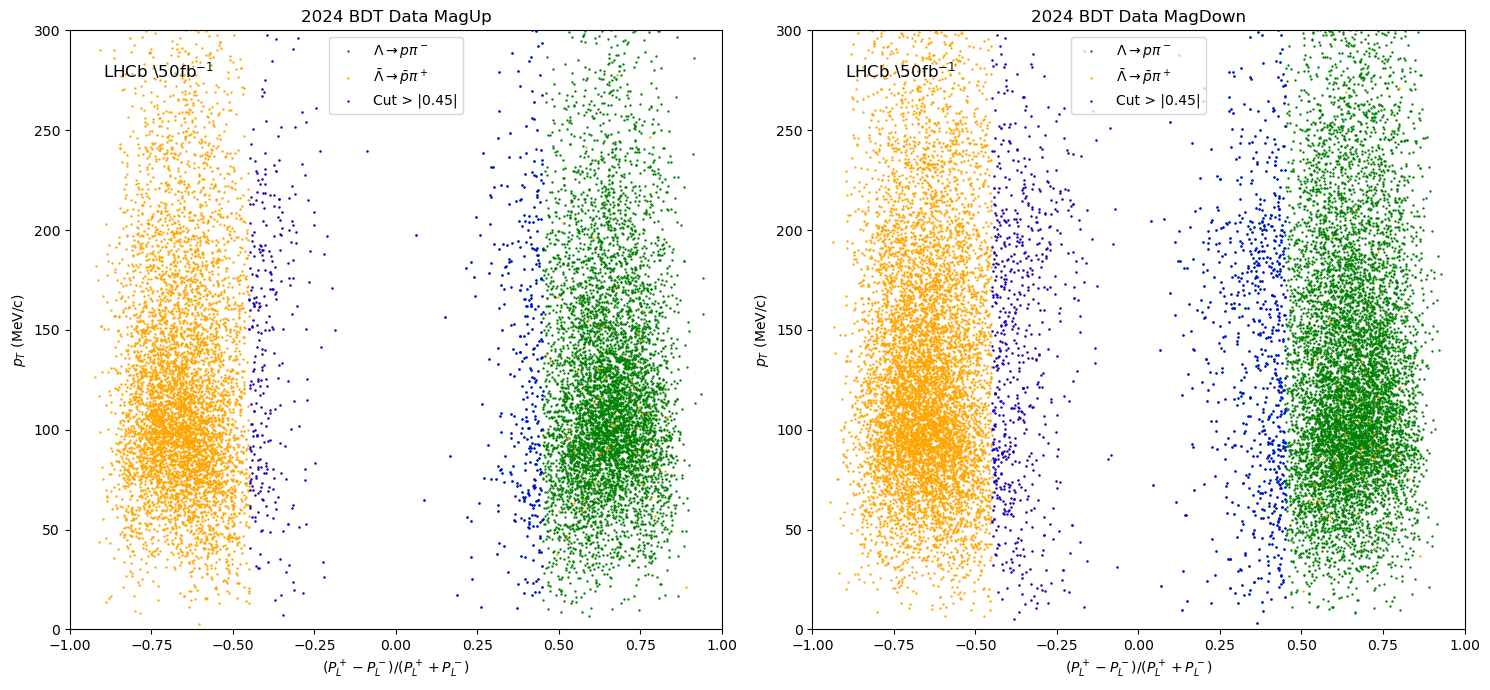

In [12]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(15, 7))  # 1 fila, 2 columnas
tam = 0.5

# Gráfico para MagUp
axs[0].scatter(data24.query(' (p_QOVERP > 0) & (MAGFIELD == True)')['alpha_combined'], 
               data24.query(' (p_QOVERP > 0)  & (MAGFIELD == True)')['pT_combined'], 
               c='green', s=tam, label=r'$\Lambda \to p \pi^-$')
axs[0].scatter(data24.query('(p_QOVERP < 0) & (MAGFIELD == True)')['alpha_combined'], 
               data24.query('(p_QOVERP < 0)  & (MAGFIELD == True)')['pT_combined'], 
               c='orange', s=tam, label=r'$\bar\Lambda \to \bar p \pi^+$')
axs[0].scatter(data24.query('(alpha_combined < 0.45)& (alpha_combined > -0.45) & (MAGFIELD == True)')['alpha_combined'], 
               data24.query('(alpha_combined < 0.45)& (alpha_combined > -0.45) &(MAGFIELD == True)')['pT_combined'], 
               c='blue', s=tam, label='Cut > |0.45|')

axs[0].set_xlim(-1, 1)
axs[0].set_ylim(0, 300)
axs[0].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[0].set_ylabel('$p_T$ (MeV/c)')
axs[0].legend()
axs[0].set_title('2024 BDT Data MagUp')

# Añadir texto "LHCb\nSimulation" al gráfico MagUp
axs[0].text(0.05, 0.95, r"LHCb \50fb$^{-1}$", transform=axs[0].transAxes, fontsize=12, color='Black', ha='left', va='top')

# Gráfico para MagDown
axs[1].scatter(data24.query(' (p_QOVERP > 0) & (MAGFIELD == False)')['alpha_combined'], 
               data24.query(' (p_QOVERP > 0)  & (MAGFIELD == False)')['pT_combined'], 
               c='green', s=tam, label=r'$\Lambda \to p \pi^-$')
axs[1].scatter(data24.query('(p_QOVERP < 0) & (MAGFIELD == False)')['alpha_combined'], 
               data24.query('(p_QOVERP < 0)  & (MAGFIELD == False)')['pT_combined'], 
               c='orange', s=tam, label=r'$\bar\Lambda \to \bar p \pi^+$')
axs[1].scatter(data24.query('(alpha_combined < 0.45)& (alpha_combined > -0.45) & (MAGFIELD == False)')['alpha_combined'], 
               data24.query('(alpha_combined < 0.45)& (alpha_combined > -0.45) &(MAGFIELD == False)')['pT_combined'], 
               c='blue', s=tam, label= 'Cut > |0.45|')
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(0, 300)
axs[1].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[1].set_ylabel('$p_T$ (MeV/c)')
axs[1].legend()
axs[1].set_title('2024 BDT Data MagDown')

# Añadir texto "LHCb\nSimulation" al gráfico MagDown
axs[1].text(0.05, 0.95, r"LHCb \50fb$^{-1}$", transform=axs[1].transAxes, fontsize=12, color='Black', ha='left', va='top')

# Ajustar layout
plt.tight_layout()
plt.show()


In [14]:
ap_data.to_pickle('AP_filter_data24.pkl')
ap_mc_data.to_pickle('AP_filter_mc_data.pkl')